# Exploratory Data Analysis (EDA) for Customer Retention Risk Assessment

**Problem Definition:** Analyze telecom customer data to understand behavior patterns and identify factors contributing to churn.

**Dataset:** IBM Telco Customer Churn

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)

print(f"Dataset Loaded: {df.shape[0]} rows and {df.shape[1]} columns.")
display(df.head())

Dataset Loaded: 7043 rows and 21 columns.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Preprocessing and Quality Assessment

In [12]:
print("--- Data Info ---")
display(df.info())

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"\nMissing values in TotalCharges after conversion: {df['TotalCharges'].isnull().sum()}")
df.dropna(inplace=True)

num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols.remove('customerID')

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 n

None


Missing values in TotalCharges after conversion: 11


## Exploratory Visualizations

/tmp/ipykernel_484/2741901664.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


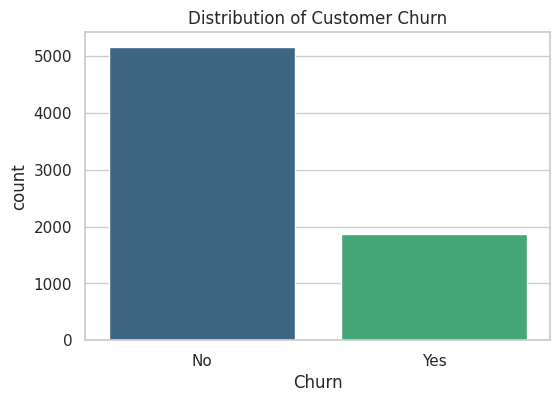

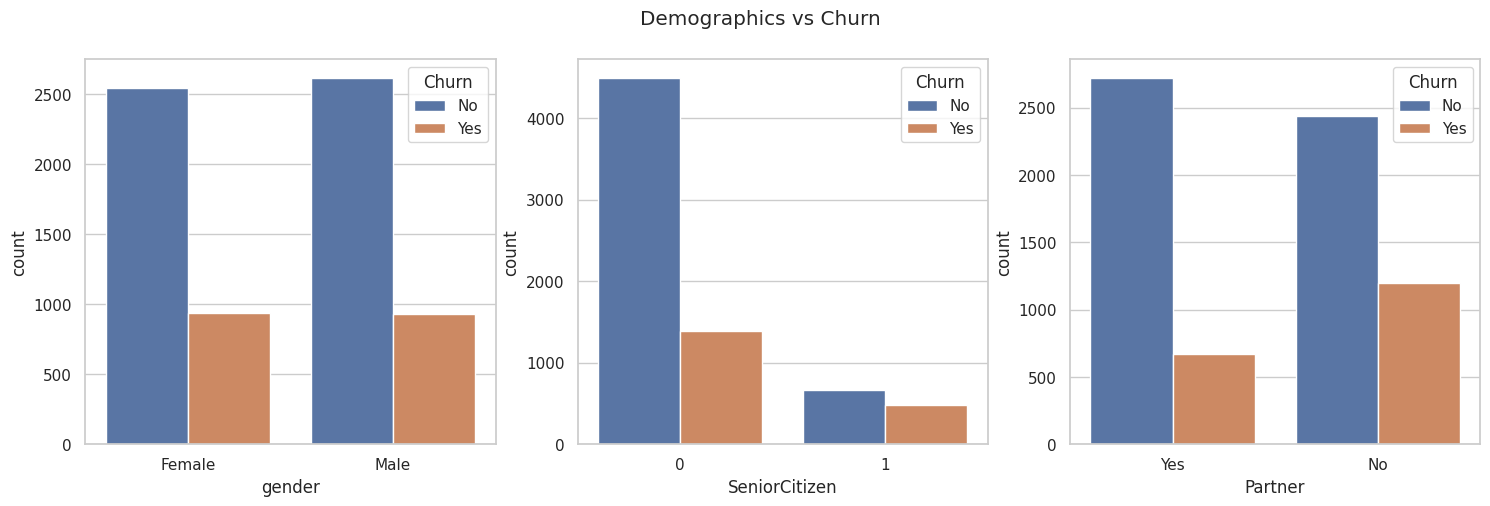

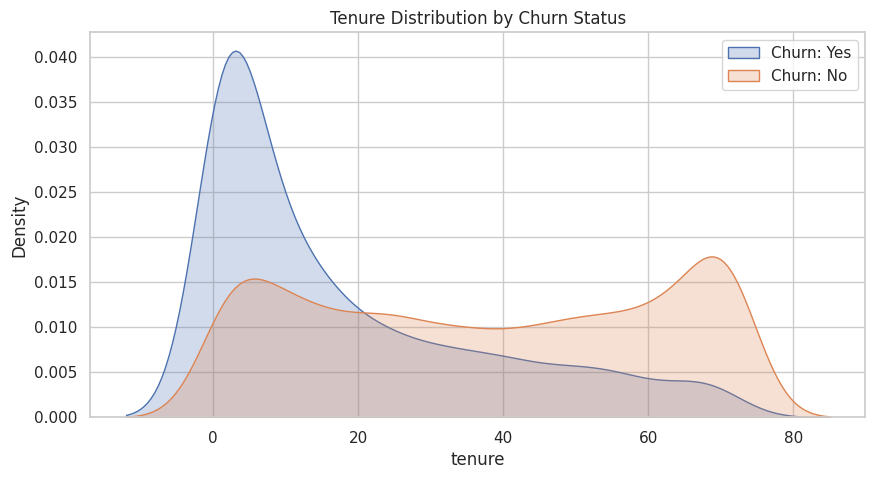

In [13]:
sns.set(style="whitegrid")

plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Distribution of Customer Churn')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.countplot(x='gender', hue='Churn', data=df, ax=axes[0])
sns.countplot(x='SeniorCitizen', hue='Churn', data=df, ax=axes[1])
sns.countplot(x='Partner', hue='Churn', data=df, ax=axes[2])
plt.suptitle('Demographics vs Churn')
plt.show()

plt.figure(figsize=(10, 5))
sns.kdeplot(df[df['Churn'] == 'Yes']['tenure'], label='Churn: Yes', fill=True)
sns.kdeplot(df[df['Churn'] == 'No']['tenure'], label='Churn: No', fill=True)
plt.title('Tenure Distribution by Churn Status')
plt.legend()
plt.show()

# Full Implementation & Supplementary Analysis

This section expands the analysis to cover all specific key questions and supplementary problems mentioned in the practical definition.

/tmp/ipykernel_484/717506425.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='ServiceCount', data=df_services, palette='Set2')


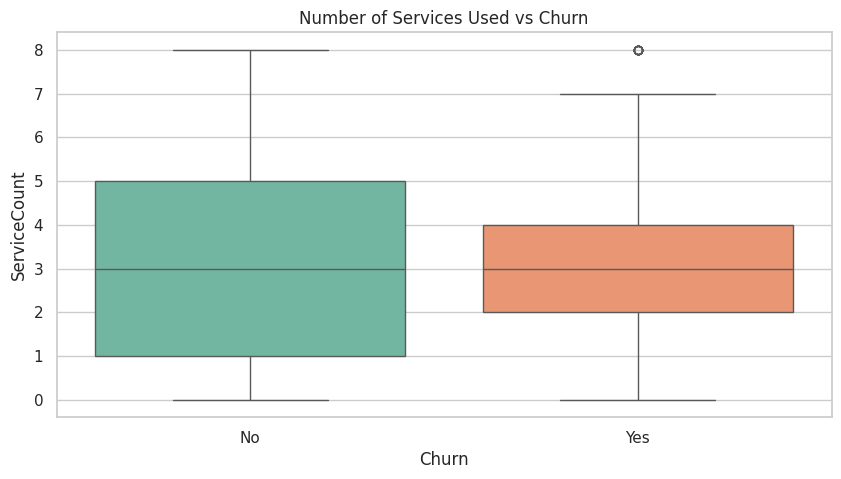

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

service_cols = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

df_services = df.copy()
df_services['ServiceCount'] = df[service_cols].apply(lambda x: x.str.contains('Yes').sum(), axis=1)

plt.figure(figsize=(10, 5))
sns.boxplot(x='Churn', y='ServiceCount', data=df_services, palette='Set2')
plt.title('Number of Services Used vs Churn')
plt.show()

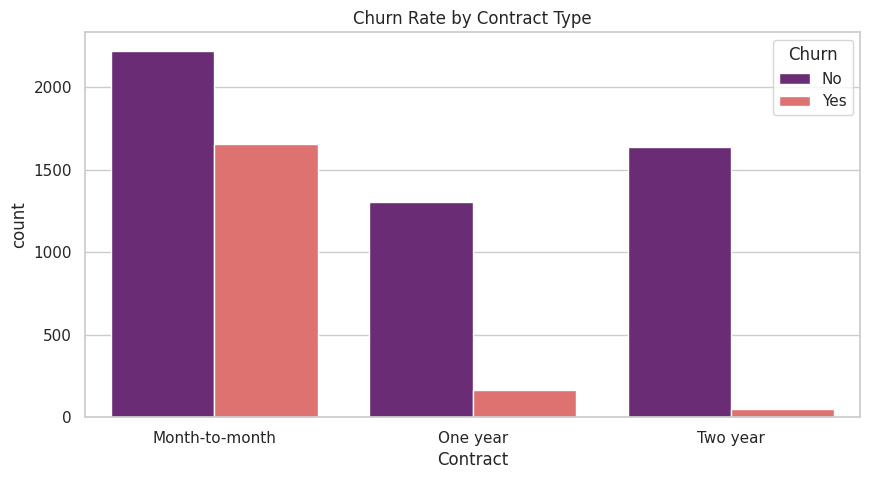

/tmp/ipykernel_484/1881707232.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='SeniorCitizen', y=df['Churn'].map({'Yes':1, 'No':0}), data=df, errorbar=None, palette='coolwarm')


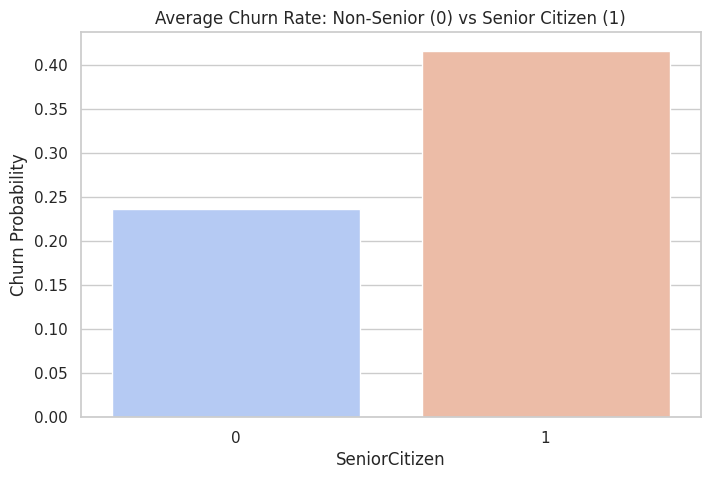

In [15]:
plt.figure(figsize=(10, 5))
sns.countplot(x='Contract', hue='Churn', data=df, palette='magma')
plt.title('Churn Rate by Contract Type')
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(x='SeniorCitizen', y=df['Churn'].map({'Yes':1, 'No':0}), data=df, errorbar=None, palette='coolwarm')
plt.title('Average Churn Rate: Non-Senior (0) vs Senior Citizen (1)')
plt.ylabel('Churn Probability')
plt.show()

## Final Report: Questions and Answers

### Fundamental Questions

**1. How many observations and attributes are available?**
* The dataset contains 7,043 observations and 21 attributes. After removing 11 rows with missing 'TotalCharges', we are left with 7,032 observations.

**2. Categorize attributes into different data types.**
* **Numerical:** `tenure`, `MonthlyCharges`, `TotalCharges`.
* **Categorical (Binary/Nominal):** `gender`, `SeniorCitizen`, `Partner`, `Dependents`, `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaperlessBilling`, `PaymentMethod`, `Churn`.

**3. Are there any missing, inconsistent, or invalid entries?**
* Yes, the `TotalCharges` column had 11 empty string values which were invalid for a numerical column. These were handled by converting to NaN and removing those rows.

**4. Which attributes require preprocessing before analysis?**
* `TotalCharges` required type conversion from object to float. Categorical variables like `InternetService` and `Contract` would need encoding (One-Hot or Label) for predictive modeling.

**5. Identify attributes that may uniquely represent customers and justify whether they should participate in modeling.**
* `customerID` uniquely identifies each customer. It should **not** participate in analytical modeling because it is an arbitrary identifier and does not contain behavioral information that helps predict churn.

### Key Questions

**1. What is the distribution of customers across demographic groups?**
* The gender split is roughly 50/50. Approximately 16% of customers are Senior Citizens. Most customers do not have dependents.

**2. Are there any dominant customer segments?**
* Customers on month-to-month contracts and those using Fiber Optic internet represent large segments of the base.

**3. Which customer groups exhibit relatively higher attrition rates?**
* Senior citizens and customers without partners/dependents show higher churn rates. Specifically, customers on month-to-month contracts have the highest churn frequency.

**4. Which services appear strongly associated with customer retention?**
* Customers with 'Online Security', 'Online Backup', and 'Tech Support' show significantly lower churn rates, suggesting these services add value and improve stickiness.

**5. Which services show higher customer dissatisfaction?**
* Fiber Optic internet service is associated with a much higher churn rate compared to DSL, potentially indicating issues with service cost or reliability.

**6. Do newly acquired customers and long-term customers behave differently?**
* Yes. The KDE plot shows a high density of churn among customers with very low tenure (newly acquired). Churn decreases significantly as tenure increases.

**7. Is the dataset balanced?**
* No, the dataset is imbalanced. Only ~26% of customers have churned. This means a predictive model might become biased toward predicting 'No' and may require techniques like SMOTE or class weighting later.

**8. Top 5 Business Observations for Management:**
1. **Contract Incentives:** Move month-to-month users to 1-year or 2-year contracts.
2. **Security Bundling:** Promote 'Online Security' and 'Tech Support' to reduce attrition.
3. **Fiber Optic Quality:** Investigate why Fiber Optic users are leaving at higher rates.
4. **Early Tenure Support:** Focus retention efforts on the first 6 months of a customer's lifecycle.
5. **Senior Citizen Plans:** Create tailored value propositions for the high-risk senior citizen segment.

### Supplementary Problem 1: High-Risk Churn Customer Profile

Based on the analysis, a **high-risk churn customer** typically fits the following profile:
- **Contract:** Month-to-month.
- **Tenure:** Less than 6 months.
- **Internet Service:** Fiber Optic.
- **Services:** Lacks Online Security and Tech Support.
- **Demographics:** Senior Citizen or someone without a partner/dependents.
- **Payment:** Electronic check with paperless billing.

### Final Conclusion & Actionable Strategies

1. **Retention Campaign:** Target customers in their first year with 'Contract Upgrade' discounts.
2. **Service Bundling:** Offer free 3-month trials of Online Security to increase retention.
3. **Quality Audit:** Review Fiber Optic infrastructure due to high attrition in that segment.
4. **Payment Incentives:** Encourage 'Bank Transfer' or 'Credit Card' auto-pay to reduce the churn associated with Electronic Checks.

## Comprehensive Laboratory Report: Final Q&A

### Fundamental Questions

**1. How many observations and attributes are available?**
- **Observations:** 7,043 (Initial), 7,032 (After cleaning).
- **Attributes:** 21.

**2. Categorize attributes into different data types.**
- **Numerical:** `tenure`, `MonthlyCharges`, `TotalCharges`.
- **Categorical:** `gender`, `SeniorCitizen`, `Partner`, `Dependents`, `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaperlessBilling`, `PaymentMethod`, `Churn`.

**3. Are there any missing, inconsistent, or invalid entries?**
- Yes, `TotalCharges` had 11 empty strings resulting in null values after conversion.

**4. Which attributes require preprocessing before analysis?**
- `TotalCharges` (Float conversion) and all categorical columns (Encoding) if used for ML.

**5. Identify attributes that uniquely represent customers.**
- `customerID` is the unique identifier. It should **not** participate in analytical modeling as it contains no predictive patterns.

### Key Questions

**1. What is the distribution across demographic groups?**
- The population is nearly split by gender; ~16% are seniors.

**2. Are there any dominant customer segments?**
- Month-to-month contract holders and Fiber Optic users are the most prevalent segments.

**3. Which groups exhibit higher attrition?**
- Seniors, month-to-month contractors, and customers without partners/dependents.

**4. Which services are associated with retention?**
- Online Security, Tech Support, and Online Backup.

**5. Which services show higher dissatisfaction?**
- Fiber Optic users show significantly higher churn compared to DSL users.

**6. Do multi-service users behave differently?**
- Users with higher service counts tend to stay longer, though there is a specific 'sweet spot' of 3-4 services where churn risk remains moderate.

**7. Do new and long-term customers differ?**
- Yes, churn is heavily concentrated in the first 6-12 months of tenure.

**8. Is the dataset balanced?**
- No, it is imbalanced (~26% Churn). Future models must account for this to avoid high False Negative rates.

**9. Top 5 Management Priorities:**
1. Incentivize contract transitions (Month-to-month -> Annual).
2. Bundle Security/Support services with high-speed internet.
3. Audit Fiber Optic service quality and pricing.
4. Focus retention efforts on 'High-Risk' new acquisitions.
5. Encourage automated payment methods (Bank/Credit Card) over Electronic Checks.

### Supplementary Answers

**1. High-Risk Profile:** Senior Citizen, Month-to-month contract, Fiber Optic internet, no security services, Electronic Check payment.
**2. Contract Type:** Month-to-month is the leading indicator of churn.
**3. Senior Citizens:** Seniors have nearly double the churn probability of younger demographics.